In [ ]:
import numpy as np
import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt

#!pip install OptiCommPy
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
from optic.models.devices import mzm, photodiode

In [ ]:
SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Fibra Óptica
---

## Sumário
---
- [Introdução](#introdução)
- [Equação Característica](#equação-caracteristica)

### Introdução
---

#### Equação de Sellmeier
A equação de Sellmeier descreve matematicamente a variação do índice de refração $n$ de um material transparente em função do comprimento de onda da luz. Em sua forma mais comum, essa equação é escrita como:

$$\begin{equation}
n^2(\omega) = 1\ + \
\sum_{j=1}^{m}\frac{B_j\omega_j^2}{\omega_j^2-\omega^2}
\end{equation},$$

#### Funções de Bessel

As funções de Bessel de primeira espécie $J_n(x)$ surgem com frequência em contextos de modulação óptica, especialmente quando há modulação senoidal ou de fase, como nos moduladores de Mach-Zehnder (MZM) operando em regime não linear. Ela é a solução da seguinte equação diferencial.

$$\begin{equation}
x^2\frac{d^2y}{dx^2} \ + \ x \frac{dy}{dx} \ + \
(x^2 - p^2) y \ = \ 0
\end{equation}$$

__Importância para as comunicações ópticas:__
- Ao modular um sinal óptico com um MZM em regime senoidal, surgem vários harmônicos no espectro, cujas amplitudes são determinadas por funções de Bessel.

- Isso permite prever o número de sidebands (faixas laterais) e sua intensidade relativa, definindo a largura de banda efetiva do sinal.

- Essencial para sistemas com modulação de fase (PM) ou modulação de frequência (FM), bem como para o dimensionamento de filtros ópticos e canais WDM.

- Também é usada para analisar o comportamento de moduladores sob diferentes profundidades de modulação.

Em resumo, as funções de Bessel fornecem a base matemática para entender como a modulação afeta o espectro óptico e como controlar a geração de harmônicos e sidebands, o que impacta diretamente a eficiência espectral e a capacidade do sistema.


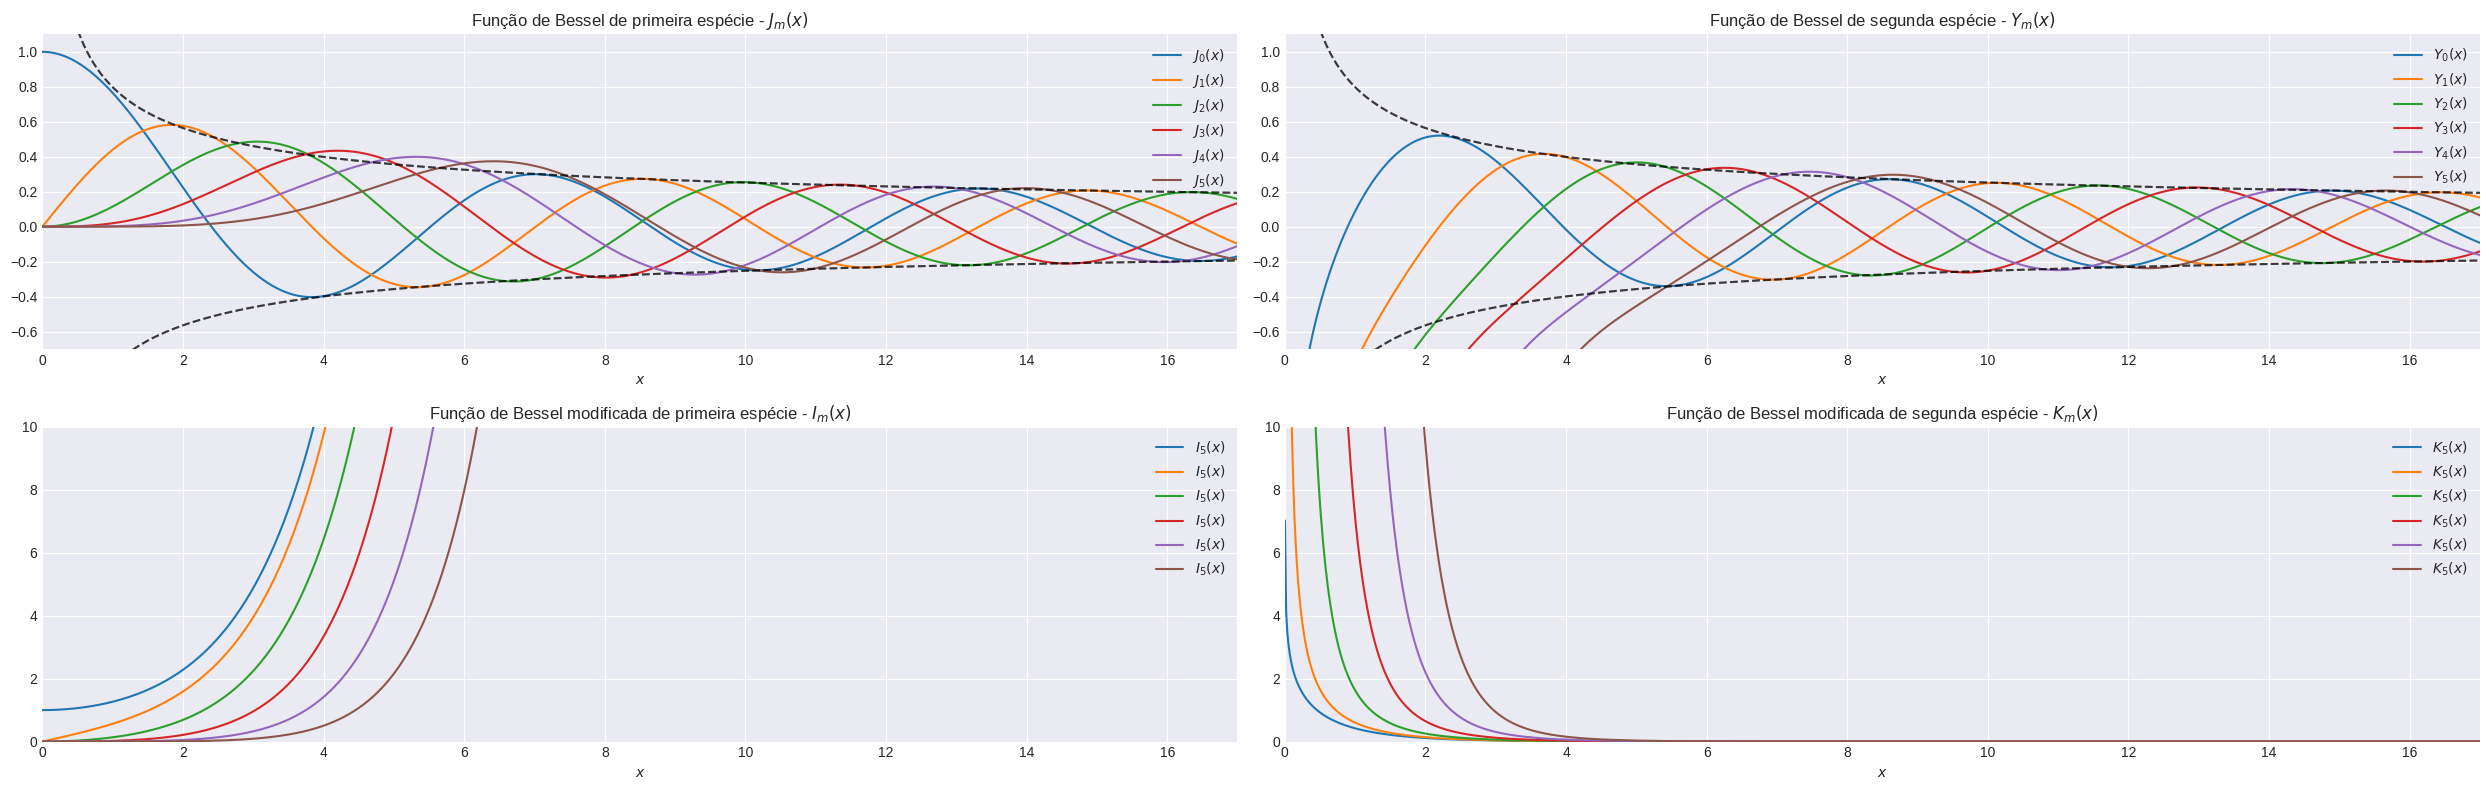

In [ ]:
#Crinado valores aleatórios para o eixo x.
x = np.linspace(0.001, 17, 1000)

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(25, 8))

for m in range(0, 6):
    axes[0,0].plot(x, sp.jv(m, x), label=f"$J_{m}(x)$")
axes[0,0].set_title("Função de Bessel de primeira espécie - ${J}_m(x)$", fontsize = 12)

for m in range(0, 6):
  axes[0,1].plot(x, sp.yv(m, x), label=f"$Y_{m}(x)$")
axes[0,1].set_title("Função de Bessel de segunda espécie - ${Y}_m(x)$", fontsize = 12)

for v in range(0, 6):
  axes[1,0].plot(x, sp.iv(v, x), label=f"$I_{m}(x)$")
axes[1,0].set_title("Função de Bessel modificada de primeira espécie - ${I}_m(x)$", fontsize = 12)

for v in range(0, 6):
  axes[1,1].plot(x, sp.kv(v, x), label=f"$K_{m}(x)$")
axes[1,1].set_title("Função de Bessel modificada de segunda espécie - ${K}_m(x)$", fontsize = 12)

for n in range(0, 2):
  for m in range(0, 2):
    axes[n,m].set_xlim((0, 17))
    axes[n,m].set_ylim((-0.7, 1.1))
    axes[n,m].set_xlabel("$x$")
    axes[n,m].legend(loc = "upper right")

  # Envelopes superior e inferior
    limite = np.sqrt(2 / (np.pi * x))
    axes[0,m].plot(x, limite, "k--", alpha = 0.5)
    axes[0,m].plot(x,-limite, "k--", alpha = 0.5)
    if n == 1: axes[n,m].set_ylim((0, 10))

plt.tight_layout()
plt.show()

### Equação característica
---
A equação característica da fibra óptica pode ser definida e dividindo em três partes temos:

$$\begin{equation}
\underbrace{\left[
\frac{J'_m(pa)}{pJ_m(pa)} + \frac{K'_m(qa)}{qK_m(qa)}
\right]}_{LHS_1} \ \
\underbrace{\left[
\frac{J'_m(pa)}{pJ_m(pa)} + \frac{n_2^2}{n_1^2} \frac{K'_m(qa)}{qK_m(qa)}
\right]}_{LHS_2} \ \ = \ \
\underbrace{
\left(\frac{m}{a}\right)^2
\left(\frac{1}{p^2} + \frac{1}{q^2}\right)
\left(\frac{1}{p^2} + \frac{n_2^2}{n_1^2}\frac{1}{p^2}\right)
}_{RHS}\end{equation}$$

>Essa equação vem do estudo das soluções do campo eletromagnético em coordenadas cilíndricas $(r, ϕ, z)$ para fibras ópticas.
  - Dentro da fibra (núcleo), a solução das equações diferenciais é feita usando as *funções de Bessel de primeira espécie:* $J_m$.
  - Fora da fibra (casca), como os campos devem decair, são usadas *funções de Bessel modificadas de segunda espécie:* $K_m$.

Onde temos as seguintes notações:
- __a__: é o raio do núcleo da fibra;
- __m__: é a ordem da função de Bessel;
- __$p^2$__ $= (n_1k_0)^2 - β^2$: parâmetro de propagação radial no núcleo;
- __$q^2$__ $= β^2 - (n_2k_0)^2$: parâmetro de decaimento na casca;
- __$n_1,n_2$__: índices de refração do núcleo e da casca;
-__β__ $= n_{eff}k_0$: constante de propagação longitudinal;
- __$n_{eff}$__: é o índice de refração efetivo que varia entre $n_2\ e\ n_1$.

In [ ]:
a    = 4.5e-6                # raio do núcleo da fibra
n1   = 1.448918              # índice do núcleo
n2   = 1.444418              # índice da casca
NA   = np.sqrt(n1**2-n2**2)  # abertura numérica
lmbd = 1550e-9               # comprimento de onda de operação
k0   = 2*np.pi/lmbd          # número de onda no espaço livre
V    = a*k0*NA               # frequência de operação normalizada
print("(n2/n1)^2 = %4.3f" % ((n2/n1)**2))
print("V = %4.2f" %(V))


(n2/n1)^2 = 0.994
V = 2.08


### Referências
---
1. **OpticalCommunications**. *Edson porto da Silva*. Disponível em: [https://github.com/edsonportosilva/OpticalCommunications/...notebooks](https://github.com/edsonportosilva/OpticalCommunications/tree/main/jupyter%20notebooks). Acessado em: 05 de maio de 2025.
2. **Função de Bessel**.*Wikipédia*. Disponível em: [wikipedia.org/..._Bessel](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_de_Bessel). Acessado em: 05 de maio de 2025.